# Video Preprocessing for Reduced Order Modelling

Before any data-driven analysis can begin, raw experimental or simulation data must be brought into a form that numerical methods can work with. For video-based fluid flow data this means:

1. **Resizing** — standardising the spatial resolution so that all frames share the same pixel dimensions,
2. **Frame extraction** — converting the video stream into a NumPy array of shape `(N_t, H, W, C)`,
3. **Grayscale conversion** — reducing each RGB frame to a single intensity channel, giving shape `(N_t, H, W)`.

The resulting array is the **snapshot matrix** — the primary input to POD/SVD analysis and neural-network time-stepping. Keeping the resolution moderate (256 × 128) balances spatial fidelity against computational cost: SVD on a $32768 \times N_t$ matrix is already expensive; a larger resolution would make it prohibitive without changing the physical content.

The video used here is a simulation of the **von Kármán vortex street** — the periodic shedding of counter-rotating vortices behind a cylindrical obstacle — a canonical benchmark for reduced-order modelling.

## 1. Background: Data Layout for ROM

Reduced-order methods operate on the **snapshot matrix** $\mathbf{X} \in \mathbb{R}^{N_x \times N_t}$, where:

- $N_x = H \times W$ is the number of spatial degrees of freedom (pixels),
- $N_t$ is the number of time snapshots (frames).

Each column $\mathbf{x}_k \in \mathbb{R}^{N_x}$ is a **flattened frame** at time $t_k$:

$$\mathbf{X} = \begin{bmatrix} | & | & & | \\ \mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_{N_t} \\ | & | & & | \end{bmatrix}$$

Grayscale intensity values are real numbers in $[0, 255]$ (uint8) or $[0, 1]$ after normalisation. For SVD we use the raw uint8 values — the decomposition is scale-invariant up to a global constant.

### Why 256 × 128?

The original video has a 2:1 aspect ratio (width:height). Downsampling to 256 × 128 preserves this ratio while keeping $N_x = 32{,}768$ — small enough that a full SVD completes in seconds on a laptop.

## 2. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 3. Inspecting the Raw Video

Before processing, we read the video metadata — frame count, frame rate, and native resolution — to understand what we are working with and to inform the choice of target resolution.

In [2]:
cap = cv2.VideoCapture('karman.mp4')

native_w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
native_h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps       = cap.get(cv2.CAP_PROP_FPS)
n_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

print(f"Native resolution : {native_w} × {native_h} px")
print(f"Frame rate        : {fps:.1f} fps")
print(f"Frame count       : {n_frames}")
print(f"Duration          : {n_frames / fps:.1f} s")

Native resolution : 640 × 320 px
Frame rate        : 25.0 fps
Frame count       : 252
Duration          : 10.1 s


## 4. Resizing the Video

We resize every frame to **256 × 128** and write the result to `output.mp4`. The function below is a reusable utility: it reads the source video frame by frame, resizes each frame with `cv2.resize`, and writes it to a new file at the same frame rate.

In [3]:
def resize_video(input_file, output_file, width, height):
    cap = cv2.VideoCapture(input_file)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_file, fourcc, cap.get(cv2.CAP_PROP_FPS), (width, height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out.write(cv2.resize(frame, (width, height)))

    cap.release()
    out.release()
    print(f"Resized video saved to '{output_file}'  ({width} × {height} px)")


TARGET_W, TARGET_H = 256, 128
resize_video('karman.mp4', 'output.mp4', TARGET_W, TARGET_H)

Resized video saved to 'output.mp4'  (256 × 128 px)


## 5. Extracting Frames

We load the resized video and collect every frame into a Python list, then convert to a NumPy array of shape `(N_t, H, W, 3)`. This colour array is saved as `frames_array_color.npy` before grayscale conversion.

In [4]:
cap = cv2.VideoCapture('output.mp4')
frames = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

frames_color = np.array(frames)
print(f"Color frames array shape: {frames_color.shape}  (N_t, H, W, C)")

np.save('frames_array_color.npy', frames_color)

Color frames array shape: (252, 128, 256, 3)  (N_t, H, W, C)


## 6. Converting to Grayscale

POD treats each pixel as a scalar state variable. Using three colour channels would triple the dimensionality without adding meaningful information for this flow — the dynamics are captured in intensity variations, not colour. We therefore convert each BGR frame to a single luminance channel:

$$I = 0.114\,B + 0.587\,G + 0.299\,R$$

This is the standard ITU-R BT.601 luminance formula applied by `cv2.COLOR_BGR2GRAY`.

In [5]:
frames_gray = np.array([
    cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in frames_color
])
print(f"Grayscale frames array shape: {frames_gray.shape}  (N_t, H, W)")

np.save('frames_array.npy', frames_gray)
print("Saved as 'frames_array.npy'")

Grayscale frames array shape: (252, 128, 256)  (N_t, H, W)
Saved as 'frames_array.npy'


## 7. Visualising Sample Frames

A quick visual check confirms that the preprocessing pipeline produced sensible output: uniform resolution, correct aspect ratio, and the characteristic vortex-shedding pattern visible even in grayscale.

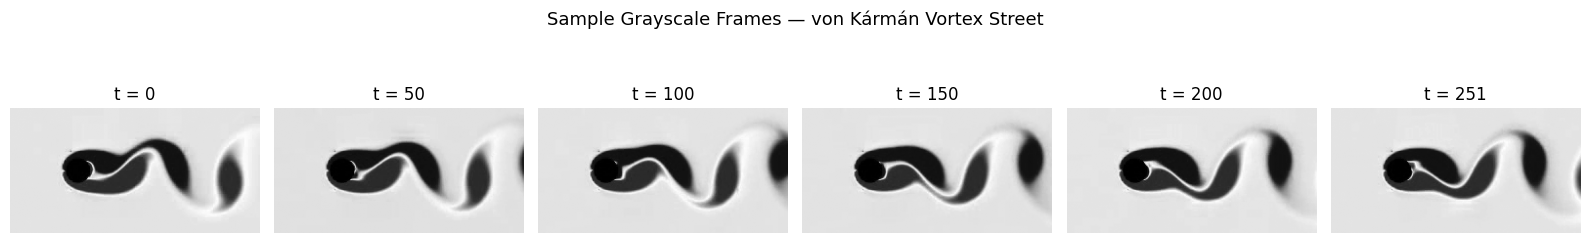

In [6]:
N_t = frames_gray.shape[0]
n_show = 6
indices = np.linspace(0, N_t - 1, n_show, dtype=int)

fig, axs = plt.subplots(1, n_show, figsize=(16, 3))
for ax, idx in zip(axs, indices):
    ax.imshow(frames_gray[idx], cmap='gray')
    ax.set_title(f't = {idx}')
    ax.axis('off')
plt.suptitle('Sample Grayscale Frames — von Kármán Vortex Street', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Summary and Key Takeaways

| Step | Input | Output | Shape |
|------|-------|--------|-------|
| Resize | `karman.mp4` (native res.) | `output.mp4` | — |
| Extract | `output.mp4` | `frames_array_color.npy` | $(N_t, 128, 256, 3)$ |
| Grayscale | color array | `frames_array.npy` | $(N_t, 128, 256)$ |

### Key takeaways

- **Consistent resolution** is mandatory before stacking frames into a snapshot matrix — SVD requires all columns to have the same length.
- **Grayscale conversion** reduces dimensionality by $3\times$ with negligible information loss for intensity-driven flows.
- The output file `frames_array.npy` is the direct input to the `POD` and `TimeSteppingNN` notebooks.